# **Marketing Campaign Analytics & Customer Conversion Dashboard**

## **Project Overview**

The project is based on a marketing organization that runs multiple digital campaigns but does not have proper analytics to measure their effectiveness.The project analyzes campaign performance, customer interactions, conversions, customer segments, regions, and marketing ROI to understand what is working and what is not.The main goal is to help the company understand customer behavior, optimize marketing strategies, improve conversion rates, and make better data-driven decisions.

## **Dataset Overview**

The dataset contains marketing campaign and customer-related information such as campaign details, marketing channels, customer demographics, geographic regions, product categories, impressions, clicks, leads, conversions, engagement, marketing spend, revenue, and purchase information.
The dataset is used to analyze campaign effectiveness, customer behavior, conversion trends, marketing performance, and return on investment.

## 1. Data Cleaning

The dataset is cleaned and prepared to ensure data quality and consistency before performing exploratory data analysis and statistical analysis.
The cleaning process includes checking the dataset structure, data types, missing values, duplicate records, date formats, categorical values, and numerical data consistency.



In [49]:
import pandas as pd
import numpy as np
df = pd.read_csv("Marketing_Dataset.csv")

In [50]:
print(df.head())

  Campaign_ID  Campaign_Name Campaign_Type Marketing_Channel  \
0        C022  Festive Offer         Sales        Google Ads   
1        C021      Mega Deal     Awareness          LinkedIn   
2        C049    Summer Sale     Awareness               NaN   
3        C039      Mega Deal         Sales          Facebook   
4        C012      Mega Deal         Sales        Google Ads   

  Campaign_Start_Date Campaign_End_Date  Customer_ID Customer_Name  Age  \
0          2024-10-01        2024-10-25       100001    Customer_1   21   
1          2025-02-15        2025-03-07       100002    Customer_2   29   
2          2024-09-21        2024-09-28       100003    Customer_3   44   
3          2024-07-05        2024-07-25       100004    Customer_4   38   
4          2025-09-07        2025-09-18       100005    Customer_5   22   

   Gender  ...    Profit Bounce_Rate Session_Duration Purchase_Amount  \
0    Male  ...  21699.99       20.13             3.32          664.24   
1  Female  ...   8

In [51]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign_ID          5020 non-null   str    
 1   Campaign_Name        5020 non-null   str    
 2   Campaign_Type        5020 non-null   str    
 3   Marketing_Channel    4608 non-null   str    
 4   Campaign_Start_Date  5020 non-null   str    
 5   Campaign_End_Date    5020 non-null   str    
 6   Customer_ID          5020 non-null   int64  
 7   Customer_Name        5020 non-null   str    
 8   Age                  5020 non-null   int64  
 9   Gender               5020 non-null   str    
 10  City                 4594 non-null   str    
 11  State                5020 non-null   str    
 12  Country              5020 non-null   str    
 13  Customer_Segment     5020 non-null   str    
 14  Product_Category     5020 non-null   str    
 15  Product_Name         5020 non-null   str    
 16 

In [52]:
print("Original Shape:", df.shape)

Original Shape: (5020, 33)


In [53]:
print(df.columns)

Index(['Campaign_ID', 'Campaign_Name', 'Campaign_Type', 'Marketing_Channel',
       'Campaign_Start_Date', 'Campaign_End_Date', 'Customer_ID',
       'Customer_Name', 'Age', 'Gender', 'City', 'State', 'Country',
       'Customer_Segment', 'Product_Category', 'Product_Name', 'Impressions',
       'Clicks', 'Leads', 'Conversions', 'Engagements', 'Ad_Spend', 'Revenue',
       'Profit', 'Bounce_Rate', 'Session_Duration', 'Purchase_Amount',
       'Device_Type', 'Payment_Method', 'Campaign_Status', 'Customer_Feedback',
       'Customer_Rating', 'Purchase_Date'],
      dtype='str')


In [54]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Campaign_ID              0
Campaign_Name            0
Campaign_Type            0
Marketing_Channel      412
Campaign_Start_Date      0
Campaign_End_Date        0
Customer_ID              0
Customer_Name            0
Age                      0
Gender                   0
City                   426
State                    0
Country                  0
Customer_Segment         0
Product_Category         0
Product_Name             0
Impressions              0
Clicks                   0
Leads                    0
Conversions              0
Engagements              0
Ad_Spend               359
Revenue                404
Profit                   0
Bounce_Rate              0
Session_Duration         0
Purchase_Amount          0
Device_Type              0
Payment_Method           0
Campaign_Status        396
Customer_Feedback      391
Customer_Rating        411
Purchase_Date            0
dtype: int64


In [55]:
print(df.dtypes)

Campaign_ID                str
Campaign_Name              str
Campaign_Type              str
Marketing_Channel          str
Campaign_Start_Date        str
Campaign_End_Date          str
Customer_ID              int64
Customer_Name              str
Age                      int64
Gender                     str
City                       str
State                      str
Country                    str
Customer_Segment           str
Product_Category           str
Product_Name               str
Impressions              int64
Clicks                   int64
Leads                    int64
Conversions              int64
Engagements              int64
Ad_Spend               float64
Revenue                float64
Profit                 float64
Bounce_Rate            float64
Session_Duration       float64
Purchase_Amount        float64
Device_Type                str
Payment_Method             str
Campaign_Status            str
Customer_Feedback          str
Customer_Rating        float64
Purchase

In [56]:
df["Campaign_Start_Date"] = pd.to_datetime(df["Campaign_Start_Date"])
df["Campaign_End_Date"] = pd.to_datetime(df["Campaign_End_Date"])
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

In [57]:
print(df.dtypes)

Campaign_ID                       str
Campaign_Name                     str
Campaign_Type                     str
Marketing_Channel                 str
Campaign_Start_Date    datetime64[us]
Campaign_End_Date      datetime64[us]
Customer_ID                     int64
Customer_Name                     str
Age                             int64
Gender                            str
City                              str
State                             str
Country                           str
Customer_Segment                  str
Product_Category                  str
Product_Name                      str
Impressions                     int64
Clicks                          int64
Leads                           int64
Conversions                     int64
Engagements                     int64
Ad_Spend                      float64
Revenue                       float64
Profit                        float64
Bounce_Rate                   float64
Session_Duration              float64
Purchase_Amo

In [58]:
numeric_cols = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Ad_Spend",
    "Revenue",
    "Profit",
    "Purchase_Amount",
    "Customer_Rating"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [59]:
print(df.describe())

              Campaign_Start_Date           Campaign_End_Date    Customer_ID  \
count                        5020                        5020    5020.000000   
mean   2024-12-15 20:18:50.199203  2025-01-03 07:05:41.354581  102490.579681   
min           2024-01-01 00:00:00         2024-01-10 00:00:00  100001.000000   
25%           2024-06-28 00:00:00         2024-07-16 00:00:00  101235.750000   
50%           2024-12-12 00:00:00         2025-01-01 00:00:00  102490.500000   
75%           2025-06-05 00:00:00         2025-06-24 06:00:00  103745.250000   
max           2025-12-01 00:00:00         2025-12-31 00:00:00  105000.000000   
std                           NaN                         NaN    1449.156571   

               Age   Impressions       Clicks        Leads  Conversions  \
count  5020.000000   5020.000000  5020.000000  5020.000000  5020.000000   
mean     38.974701  25467.597809  2565.069323  1314.367131   657.629084   
min      18.000000   1001.000000    50.000000    10.00

In [60]:
print(df["Marketing_Channel"].unique())

<ArrowStringArray>
['Google Ads', 'LinkedIn', nan, 'Facebook', 'Email', 'Instagram']
Length: 6, dtype: str


In [61]:
print(df.nunique())

Campaign_ID              50
Campaign_Name             5
Campaign_Type             3
Marketing_Channel         5
Campaign_Start_Date     701
Campaign_End_Date       720
Customer_ID            5000
Customer_Name          5000
Age                      43
Gender                    2
City                      5
State                     4
Country                   1
Customer_Segment          3
Product_Category          5
Product_Name             10
Impressions            4751
Clicks                 3362
Leads                  2500
Conversions            1727
Engagements            3991
Ad_Spend               4631
Revenue                4595
Profit                 4990
Bounce_Rate            3407
Session_Duration       1358
Purchase_Amount        4099
Device_Type               3
Payment_Method            4
Campaign_Status           3
Customer_Feedback         3
Customer_Rating           5
Purchase_Date           720
dtype: int64


In [62]:
categorical_columns = [
    "Marketing_Channel",
    "City",
    "Campaign_Status",
    "Customer_Feedback"
]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [63]:
numeric_columns = [
    "Ad_Spend",
    "Revenue",
    "Customer_Rating"
]
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [64]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Campaign_ID            0
Campaign_Name          0
Campaign_Type          0
Marketing_Channel      0
Campaign_Start_Date    0
Campaign_End_Date      0
Customer_ID            0
Customer_Name          0
Age                    0
Gender                 0
City                   0
State                  0
Country                0
Customer_Segment       0
Product_Category       0
Product_Name           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Engagements            0
Ad_Spend               0
Revenue                0
Profit                 0
Bounce_Rate            0
Session_Duration       0
Purchase_Amount        0
Device_Type            0
Payment_Method         0
Campaign_Status        0
Customer_Feedback      0
Customer_Rating        0
Purchase_Date          0
dtype: int64


In [65]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [66]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 20


In [67]:
duplicates = df[df.duplicated()]
print(duplicates)

     Campaign_ID  Campaign_Name Campaign_Type Marketing_Channel  \
5000        C022  Festive Offer         Sales        Google Ads   
5001        C021      Mega Deal     Awareness          LinkedIn   
5002        C049    Summer Sale     Awareness          LinkedIn   
5003        C039      Mega Deal         Sales          Facebook   
5004        C012      Mega Deal         Sales        Google Ads   
5005        C008     New Launch     Promotion        Google Ads   
5006        C049     Flash Sale     Promotion          Facebook   
5007        C045  Festive Offer         Sales             Email   
5008        C005    Summer Sale     Awareness          Facebook   
5009        C050     New Launch         Sales          LinkedIn   
5010        C007  Festive Offer     Promotion          LinkedIn   
5011        C028    Summer Sale     Awareness        Google Ads   
5012        C019    Summer Sale     Awareness          LinkedIn   
5013        C013      Mega Deal     Awareness        Google Ad

In [68]:
df = df.drop_duplicates()

In [69]:
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [70]:
date_columns = [
    "Campaign_Start_Date",
    "Campaign_End_Date",
    "Purchase_Date"
]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [71]:
print(df[date_columns].dtypes)

Campaign_Start_Date    datetime64[us]
Campaign_End_Date      datetime64[us]
Purchase_Date          datetime64[us]
dtype: object


In [72]:
numeric_columns = [
    "Age",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Engagements",
    "Ad_Spend",
    "Revenue",
    "Profit",
    "Bounce_Rate",
    "Session_Duration",
    "Purchase_Amount",
    "Customer_Rating"
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [73]:
integer_columns = [
    "Age",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Engagements",
    "Customer_Rating"
]
for col in integer_columns:
    df[col] = df[col].astype("Int64")

In [74]:
print(df.dtypes)

Campaign_ID                       str
Campaign_Name                     str
Campaign_Type                     str
Marketing_Channel                 str
Campaign_Start_Date    datetime64[us]
Campaign_End_Date      datetime64[us]
Customer_ID                     int64
Customer_Name                     str
Age                             Int64
Gender                            str
City                              str
State                             str
Country                           str
Customer_Segment                  str
Product_Category                  str
Product_Name                      str
Impressions                     Int64
Clicks                          Int64
Leads                           Int64
Conversions                     Int64
Engagements                     Int64
Ad_Spend                      float64
Revenue                       float64
Profit                        float64
Bounce_Rate                   float64
Session_Duration              float64
Purchase_Amo

In [82]:
print("\nFinal Dataset Shape:")
print(df.shape)
print("\nMedian:")
print(df.median(numeric_only=True))


Final Dataset Shape:
(5000, 33)

Median:
Customer_ID          102500.5
Age                      39.0
Impressions           25471.5
Clicks                 1960.0
Leads                   792.0
Conversions             287.0
Engagements            3663.0
Ad_Spend              5184.29
Revenue             11659.285
Profit                 6167.1
Bounce_Rate            50.475
Session_Duration        7.885
Purchase_Amount        37.005
Customer_Rating           3.0
dtype: Float64


In [83]:
# SAVE CLEANED DATASET
output_file = "Marketing_Dataset.csv"

df.to_csv(output_file, index=False)

print("\nCleaned dataset saved successfully!")
print("File saved at:", output_file)


Cleaned dataset saved successfully!
File saved at: Marketing_Dataset.csv


In [92]:
print(df["Customer_Segment"].value_counts())

Customer_Segment
Returning    1709
New          1676
VIP          1615
Name: count, dtype: int64


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
customer_revenue = df.groupby("Customer_Segment")["Revenue"].sum()
print(customer_revenue)

Customer_Segment
New          2.158163e+07
Returning    2.224869e+07
VIP          2.169958e+07
Name: Revenue, dtype: float64


In [95]:
#Perform exploratory data analysis (EDA) to identify customer and campaign patterns.
#3. CUSTOMER PATTERN ANALYSIS
# ------------------------------------------

# Customers by segment
customer_segment = df.groupby("Customer_Segment").agg(
    Customers=("Customer_ID", "nunique"),
    Revenue=("Revenue", "sum"),
    Conversions=("Conversions", "sum"),
    Engagements=("Engagements", "sum")
).sort_values("Revenue", ascending=False)

print("\n===== CUSTOMER SEGMENT ANALYSIS =====")
print(customer_segment)


===== CUSTOMER SEGMENT ANALYSIS =====
                  Customers       Revenue  Conversions  Engagements
Customer_Segment                                                   
Returning              1709  2.224869e+07      1137402      8691911
VIP                    1615  2.169958e+07      1059385      8406112
New                    1676  2.158163e+07      1095098      8419139


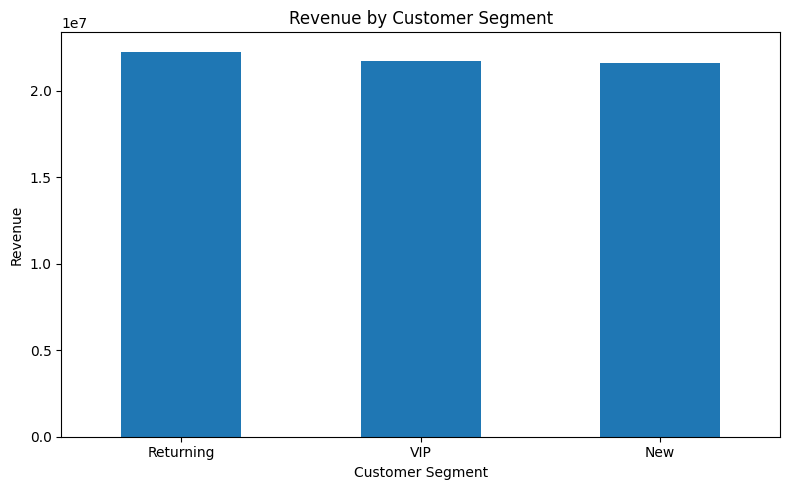

In [96]:
# Customer segment revenue chart
customer_segment["Revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [97]:
campaign_performance = df.groupby("Campaign_Name").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Leads=("Leads", "sum"),
    Conversions=("Conversions", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).sort_values("Revenue", ascending=False)

print(campaign_performance)

               Impressions   Clicks    Leads  Conversions    Ad_Spend  \
Campaign_Name                                                           
Mega Deal         27403658  2664619  1353306       680228  5467489.93   
New Launch        25394886  2519943  1291181       640443  5363597.44   
Flash Sale        26167433  2632990  1336624       674116  5293834.37   
Summer Sale       24338367  2529976  1280122       646257  4980675.06   
Festive Offer     24020779  2483870  1318325       650841  4924033.32   

                    Revenue      Profit  
Campaign_Name                            
Mega Deal      1.365331e+07  8279419.68  
New Launch     1.363934e+07  8448281.96  
Flash Sale     1.319315e+07  8036124.67  
Summer Sale    1.268411e+07  7812388.71  
Festive Offer  1.235999e+07  7531144.68  


In [98]:
best_campaign = campaign_performance["Revenue"].idxmax()

print("Best Campaign:", best_campaign)
print("Revenue:", campaign_performance.loc[best_campaign, "Revenue"])

Best Campaign: Mega Deal
Revenue: 13653314.84


In [100]:
#2. Marketing Channel Performance
channel_performance = df.groupby("Marketing_Channel").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Leads=("Leads", "sum"),
    Conversions=("Conversions", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).sort_values("Revenue", ascending=False)

print(channel_performance)

                   Impressions   Clicks    Leads  Conversions    Ad_Spend  \
Marketing_Channel                                                           
LinkedIn              34043510  3288230  1714723       866430  6825703.86   
Instagram             24070042  2443419  1231922       581792  4960692.53   
Email                 23666707  2346298  1232879       611090  4909827.83   
Facebook              22754686  2370986  1232107       637028  4670855.16   
Google Ads            22790178  2382465  1167927       595545  4662550.74   

                        Revenue       Profit  
Marketing_Channel                             
LinkedIn           1.724839e+07  10550244.75  
Instagram          1.246045e+07   7632170.91  
Email              1.244988e+07   7685095.19  
Facebook           1.179290e+07   7103116.05  
Google Ads         1.157828e+07   7136732.80  


In [102]:
best_channel = channel_performance["Revenue"].idxmax()
print("Best Marketing Channel:", best_channel)

Best Marketing Channel: LinkedIn


In [103]:
#3. Customer Segment Performance

In [104]:
segment_performance = df.groupby("Customer_Segment").agg(
    Customers=("Customer_ID", "nunique"),
    Conversions=("Conversions", "sum"),
    Revenue=("Revenue", "sum"),
    Purchase_Amount=("Purchase_Amount", "sum"),
    Engagements=("Engagements", "sum")
).sort_values("Revenue", ascending=False)

print(segment_performance)

                  Customers  Conversions       Revenue  Purchase_Amount  \
Customer_Segment                                                          
Returning              1709      1137402  2.224869e+07        481870.13   
VIP                    1615      1059385  2.169958e+07        493861.52   
New                    1676      1095098  2.158163e+07        587520.88   

                  Engagements  
Customer_Segment               
Returning             8691911  
VIP                   8406112  
New                   8419139  


In [105]:
best_segment = segment_performance["Revenue"].idxmax()
print("Best Customer Segment:", best_segment)

Best Customer Segment: Returning


In [108]:
#4. Geographic Region Performance
#Use State as your geographic region.
region_performance = df.groupby("State").agg(
    Customers=("Customer_ID", "nunique"),
    Clicks=("Clicks", "sum"),
    Conversions=("Conversions", "sum"),
    Revenue=("Revenue", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Profit=("Profit", "sum")
).sort_values("Revenue", ascending=False)

print(region_performance)

             Customers   Clicks  Conversions       Revenue     Ad_Spend  \
State                                                                     
Maharashtra       2018  5356349      1360214  2.654735e+07  10557159.32   
Telangana         1015  2542698       655360  1.339753e+07   5356472.07   
Karnataka         1007  2564069       662323  1.302342e+07   5119229.52   
Delhi              960  2368282       613988  1.256159e+07   4996769.21   

                  Profit  
State                     
Maharashtra  16180862.24  
Telangana     8247714.49  
Karnataka     8007218.87  
Delhi         7671564.10  


In [109]:
best_region = region_performance["Revenue"].idxmax()
print("Best Region:", best_region)

Best Region: Maharashtra


In [110]:
#5. Product Category Performance
product_performance = df.groupby("Product_Category").agg(
    Customers=("Customer_ID", "nunique"),
    Clicks=("Clicks", "sum"),
    Conversions=("Conversions", "sum"),
    Revenue=("Revenue", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Profit=("Profit", "sum")
).sort_values("Revenue", ascending=False)

print(product_performance)

                  Customers   Clicks  Conversions       Revenue    Ad_Spend  \
Product_Category                                                              
Home                   1022  2571351       648848  1.357171e+07  5376568.61   
Fashion                 987  2566645       618043  1.324746e+07  5164123.93   
Beauty                 1003  2645093       708123  1.317917e+07  5172281.99   
Grocery                1009  2510673       684640  1.292850e+07  5251956.05   
Electronics             979  2537636       632231  1.260306e+07  5064699.54   

                      Profit  
Product_Category              
Home              8273571.37  
Fashion           8204016.54  
Beauty            8079580.51  
Grocery           7858857.90  
Electronics       7691333.38  


In [111]:
best_product = product_performance["Revenue"].idxmax()
print("Best Product Category:", best_product)

Best Product Category: Home


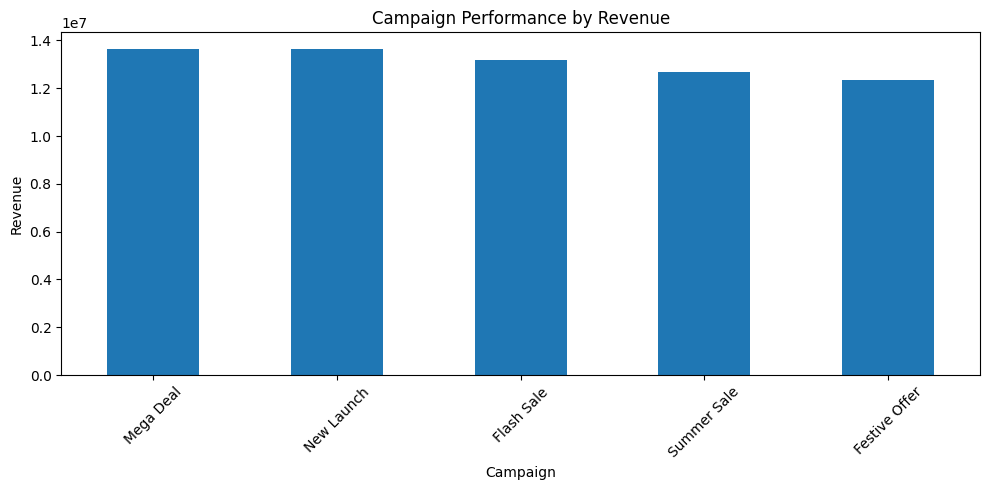

In [112]:
#6. Create Charts
campaign_performance["Revenue"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Campaign Performance by Revenue")
plt.xlabel("Campaign")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

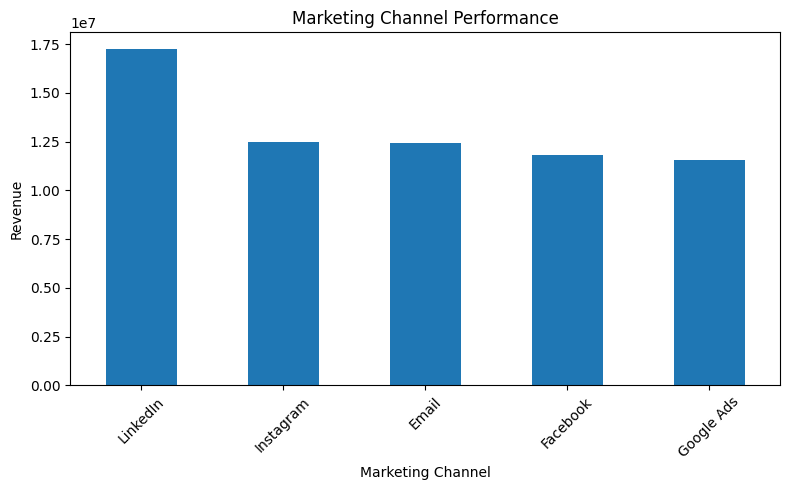

In [115]:
#Channel Revenue

channel_performance["Revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Marketing Channel Performance")
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

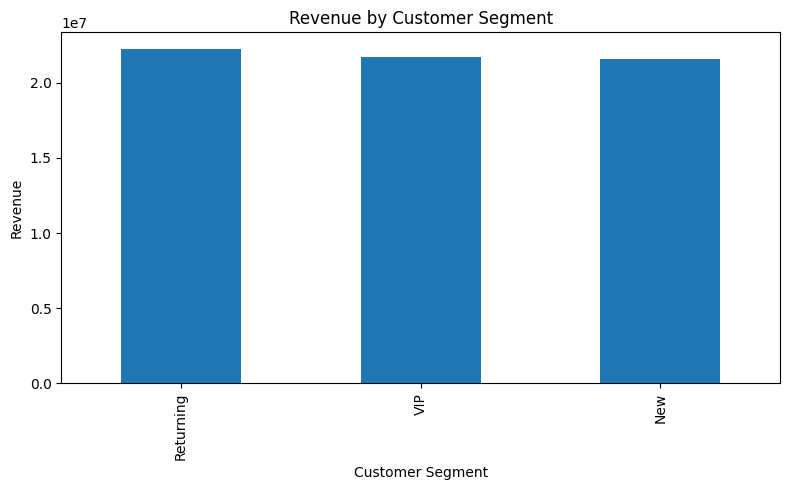

In [118]:
#Customer Segment Revenue

segment_performance["Revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

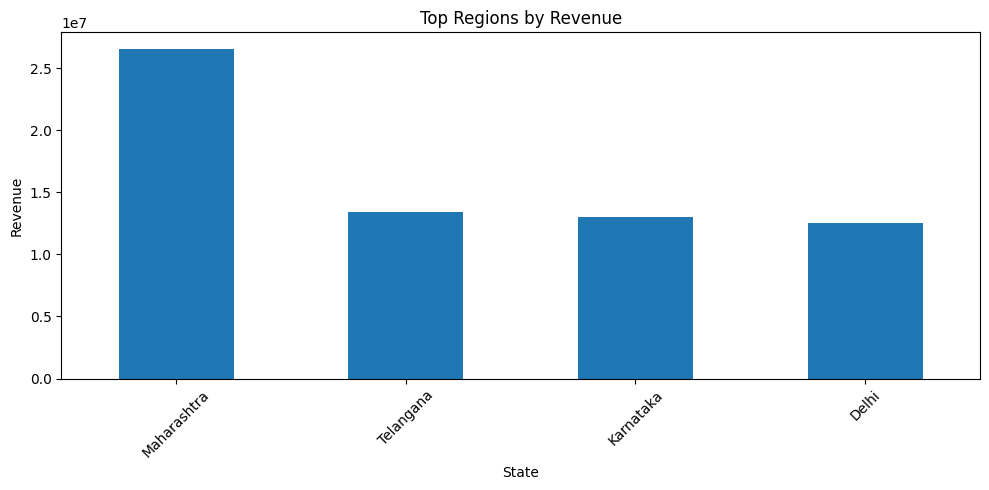

In [119]:
#Region Revenue

region_performance["Revenue"].head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Regions by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

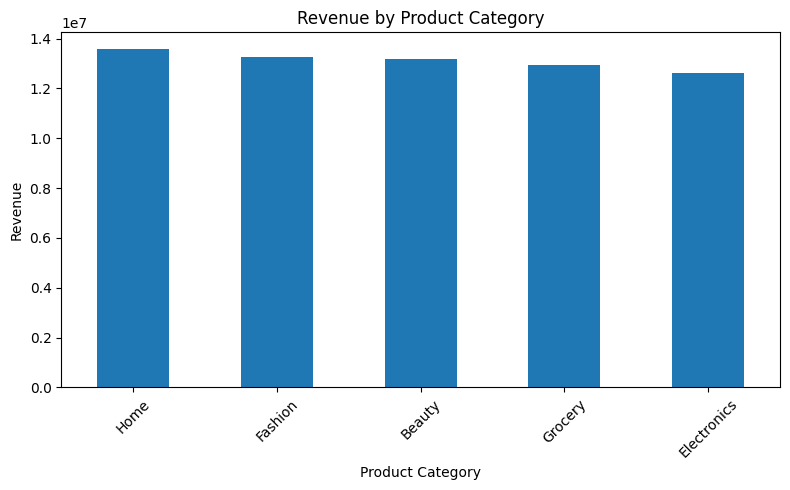

In [120]:
#Product Category Revenue

product_performance["Revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 1. Analyze Customer Journey and Conversion Funnel
Your customer journey is:
Impressions → Clicks → Leads → Conversions
Step 1: Calculate funnel stages

In [125]:
funnel = pd.DataFrame({
    "Stage": [
        "Impressions",
        "Clicks",
        "Leads",
        "Conversions"
    ],
    "Customers": [
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Leads"].sum(),
        df["Conversions"].sum()
    ]
})

print("===== CUSTOMER CONVERSION FUNNEL =====")
print(funnel)

===== CUSTOMER CONVERSION FUNNEL =====
         Stage  Customers
0  Impressions  127325123
1       Clicks   12831398
2        Leads    6579558
3  Conversions    3291885


# Step 2: Calculate conversion percentages

In [127]:
impressions = df["Impressions"].sum()
clicks = df["Clicks"].sum()
leads = df["Leads"].sum()
conversions = df["Conversions"].sum()

ctr = (clicks / impressions) * 100
lead_rate = (leads / clicks) * 100
conversion_rate = (conversions / leads) * 100

print("\n===== FUNNEL RATES =====")
print("Click Through Rate:", round(ctr, 2), "%")
print("Lead Rate:", round(lead_rate, 2), "%")
print("Lead to Conversion Rate:", round(conversion_rate, 2), "%")


===== FUNNEL RATES =====
Click Through Rate: 10.08 %
Lead Rate: 51.28 %
Lead to Conversion Rate: 50.03 %


# Step 3: Visualize funnel

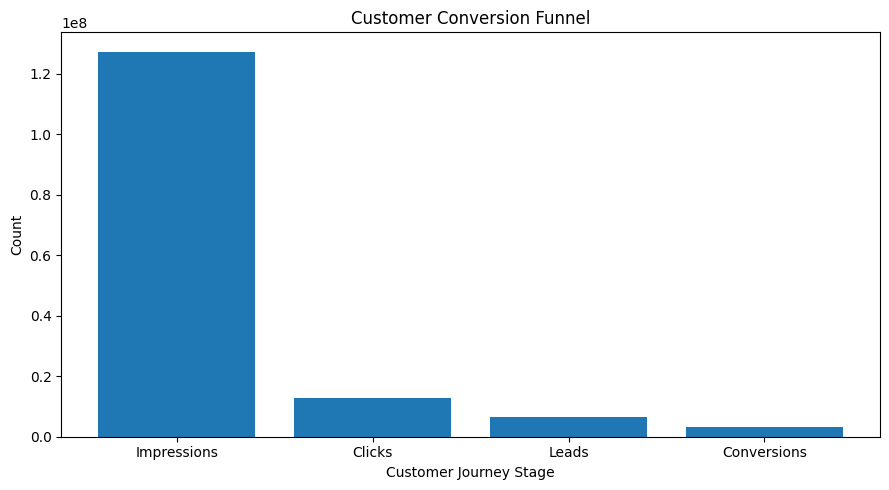

In [129]:
plt.figure(figsize=(9, 5))

plt.bar(
    funnel["Stage"],
    funnel["Customers"]
)

plt.title("Customer Conversion Funnel")
plt.xlabel("Customer Journey Stage")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# 2. Identify High-Performing and Low-Performing Campaigns

We will use Revenue, Conversions, Profit, and ROMI to evaluate campaigns.

Step 1: Campaign performance

In [136]:
campaign_performance = df.groupby("Campaign_Name").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Leads=("Leads", "sum"),
    Conversions=("Conversions", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
)

# Step 2: Calculate campaign KPIs

In [135]:
campaign_performance["CTR"] = (
    campaign_performance["Clicks"] /
    campaign_performance["Impressions"].replace(0, np.nan)
) * 100

campaign_performance["Conversion_Rate"] = (
    campaign_performance["Conversions"] /
    campaign_performance["Leads"].replace(0, np.nan)
) * 100

campaign_performance["ROMI"] = (
    (campaign_performance["Revenue"] -
     campaign_performance["Ad_Spend"]) /
    campaign_performance["Ad_Spend"].replace(0, np.nan)
) * 100

# Step 3: High-performing campaigns

In [139]:
high_performing = campaign_performance.sort_values(
    "Revenue",
    ascending=False
).head(5)

print("===== HIGH-PERFORMING CAMPAIGNS =====")
print(high_performing.round(2))

===== HIGH-PERFORMING CAMPAIGNS =====
               Impressions   Clicks    Leads  Conversions    Ad_Spend  \
Campaign_Name                                                           
Mega Deal         27403658  2664619  1353306       680228  5467489.93   
New Launch        25394886  2519943  1291181       640443  5363597.44   
Flash Sale        26167433  2632990  1336624       674116  5293834.37   
Summer Sale       24338367  2529976  1280122       646257  4980675.06   
Festive Offer     24020779  2483870  1318325       650841  4924033.32   

                   Revenue      Profit  
Campaign_Name                           
Mega Deal      13653314.84  8279419.68  
New Launch     13639341.09  8448281.96  
Flash Sale     13193149.57  8036124.67  
Summer Sale    12684106.34  7812388.71  
Festive Offer  12359989.63  7531144.68  


# Step 4: Low-performing campaigns

In [141]:
low_performing = campaign_performance.sort_values(
    "Revenue",
    ascending=True
).head(5)

print("\n===== LOW-PERFORMING CAMPAIGNS =====")
print(low_performing.round(2))


===== LOW-PERFORMING CAMPAIGNS =====
               Impressions   Clicks    Leads  Conversions    Ad_Spend  \
Campaign_Name                                                           
Festive Offer     24020779  2483870  1318325       650841  4924033.32   
Summer Sale       24338367  2529976  1280122       646257  4980675.06   
Flash Sale        26167433  2632990  1336624       674116  5293834.37   
New Launch        25394886  2519943  1291181       640443  5363597.44   
Mega Deal         27403658  2664619  1353306       680228  5467489.93   

                   Revenue      Profit  
Campaign_Name                           
Festive Offer  12359989.63  7531144.68  
Summer Sale    12684106.34  7812388.71  
Flash Sale     13193149.57  8036124.67  
New Launch     13639341.09  8448281.96  
Mega Deal      13653314.84  8279419.68  


# Step 5: Best campaign

In [144]:
best_campaign = campaign_performance["Revenue"].idxmax()
print("\nBest Performing Campaign:", best_campaign)


Best Performing Campaign: Mega Deal


# Step 6: Worst campaign

In [146]:
worst_campaign = campaign_performance["Revenue"].idxmin()
print("Lowest Performing Campaign:", worst_campaign)

Lowest Performing Campaign: Festive Offer


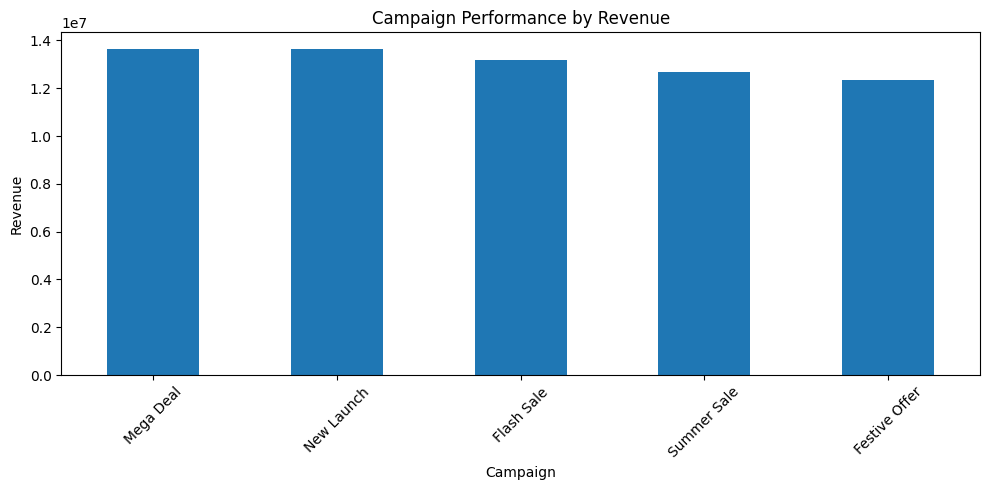

In [147]:
campaign_performance["Revenue"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Campaign Performance by Revenue")
plt.xlabel("Campaign")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# A. Demographic Segmentation

In [149]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 100],
    labels=[
        "18-25",
        "26-35",
        "36-50",
        "51+"
    ]
)

print("===== AGE GROUP DISTRIBUTION =====")
print(df["Age_Group"].value_counts())

===== AGE GROUP DISTRIBUTION =====
Age_Group
36-50    1730
26-35    1200
51+      1162
18-25     908
Name: count, dtype: int64


# Revenue by age group

In [151]:
age_analysis = df.groupby(
    "Age_Group",
    observed=True
).agg(
    Customers=("Customer_ID", "nunique"),
    Revenue=("Revenue", "sum"),
    Conversions=("Conversions", "sum")
)

print("\n===== AGE GROUP PERFORMANCE =====")
print(age_analysis)


===== AGE GROUP PERFORMANCE =====
           Customers       Revenue  Conversions
Age_Group                                      
18-25            908  1.171321e+07       640688
26-35           1200  1.587258e+07       784342
36-50           1730  2.243943e+07      1122752
51+             1162  1.550469e+07       744103


In [152]:
gender_analysis = df.groupby("Gender").agg(
    Customers=("Customer_ID", "nunique"),
    Revenue=("Revenue", "sum"),
    Conversions=("Conversions", "sum"),
    Purchase_Amount=("Purchase_Amount", "sum")
)

print("\n===== GENDER ANALYSIS =====")
print(gender_analysis)


===== GENDER ANALYSIS =====
        Customers       Revenue  Conversions  Purchase_Amount
Gender                                                       
Female       2502  3.309241e+07      1681570        819658.07
Male         2498  3.243749e+07      1610315        743594.46


# 4. Purchase Behavior Segmentation

In [154]:
df["Purchase_Behavior"] = pd.cut(
    df["Purchase_Amount"],
    bins=[-1, 1000, 5000, float("inf")],
    labels=[
        "Low Purchase",
        "Medium Purchase",
        "High Purchase"
    ]
)

In [155]:
purchase_analysis = df.groupby(
    "Purchase_Behavior",
    observed=True
).agg(
    Customers=("Customer_ID", "nunique"),
    Total_Purchase=("Purchase_Amount", "sum"),
    Revenue=("Revenue", "sum"),
    Conversions=("Conversions", "sum")
)

print("\n===== PURCHASE BEHAVIOR =====")
print(purchase_analysis)


===== PURCHASE BEHAVIOR =====
                   Customers  Total_Purchase       Revenue  Conversions
Purchase_Behavior                                                      
Low Purchase            4708       478229.71  6.016083e+07      3289258
Medium Purchase          231       473829.78  4.171568e+06         2479
High Purchase             61       611193.04  1.197503e+06          148


# 5. Engagement Level Segmentation

In [157]:
df["Engagement_Level"] = pd.cut(
    df["Engagements"],
    bins=[-1, 10, 50, float("inf")],
    labels=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ]
)

In [158]:
engagement_analysis = df.groupby(
    "Engagement_Level",
    observed=True
).agg(
    Customers=("Customer_ID", "nunique"),
    Engagements=("Engagements", "sum"),
    Conversions=("Conversions", "sum"),
    Revenue=("Revenue", "sum")
)

print("\n===== ENGAGEMENT LEVEL =====")
print(engagement_analysis)


===== ENGAGEMENT LEVEL =====
                  Customers  Engagements  Conversions       Revenue
Engagement_Level                                                   
High Engagement        5000     25517162      3291885  6.552990e+07


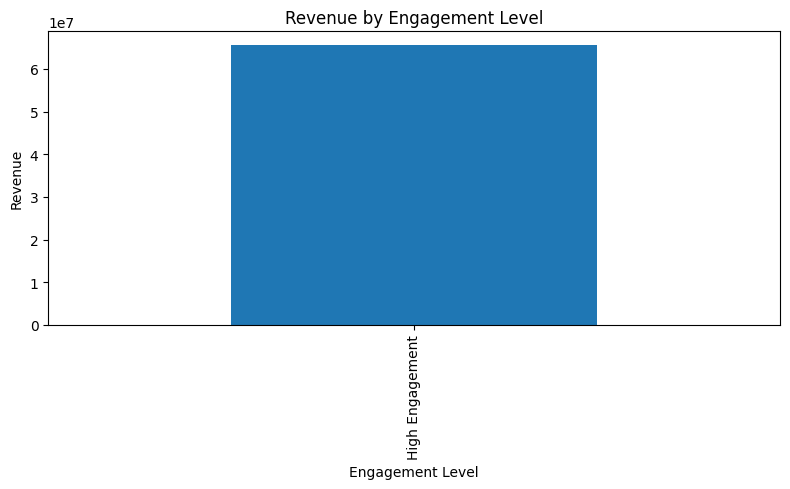

In [159]:
engagement_analysis["Revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# 6. Analyze Campaign Trends Over Time

In [161]:
df["Campaign_Start_Date"] = pd.to_datetime(
    df["Campaign_Start_Date"],
    errors="coerce"
)

In [162]:
df["Campaign_Month"] = df[
    "Campaign_Start_Date"
].dt.to_period("M")

# Monthly campaign performance

In [164]:
monthly_campaign = df.groupby(
    "Campaign_Month"
).agg(
    Campaigns=("Campaign_ID", "nunique"),
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Leads=("Leads", "sum"),
    Conversions=("Conversions", "sum"),
    Ad_Spend=("Ad_Spend", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
)

print("===== MONTHLY CAMPAIGN TREND =====")
print(monthly_campaign)

===== MONTHLY CAMPAIGN TREND =====
                Campaigns  Impressions  Clicks   Leads  Conversions  \
Campaign_Month                                                        
2024-01                50      5479335  546962  296543       171268   
2024-02                50      4903844  464664  242414       116856   
2024-03                49      5226628  513421  258775       131408   
2024-04                49      5263216  556072  279480       131391   
2024-05                49      6007268  591037  309133       155361   
2024-06                50      5473910  576811  282084       151645   
2024-07                49      5642813  599583  297350       133287   
2024-08                50      5959081  604563  312795       154224   
2024-09                49      5447534  542441  279872       139921   
2024-10                49      5966558  632165  322980       149283   
2024-11                49      5684411  591707  294910       151251   
2024-12                48      5809609  58

# 7. Monthly Revenue Trend

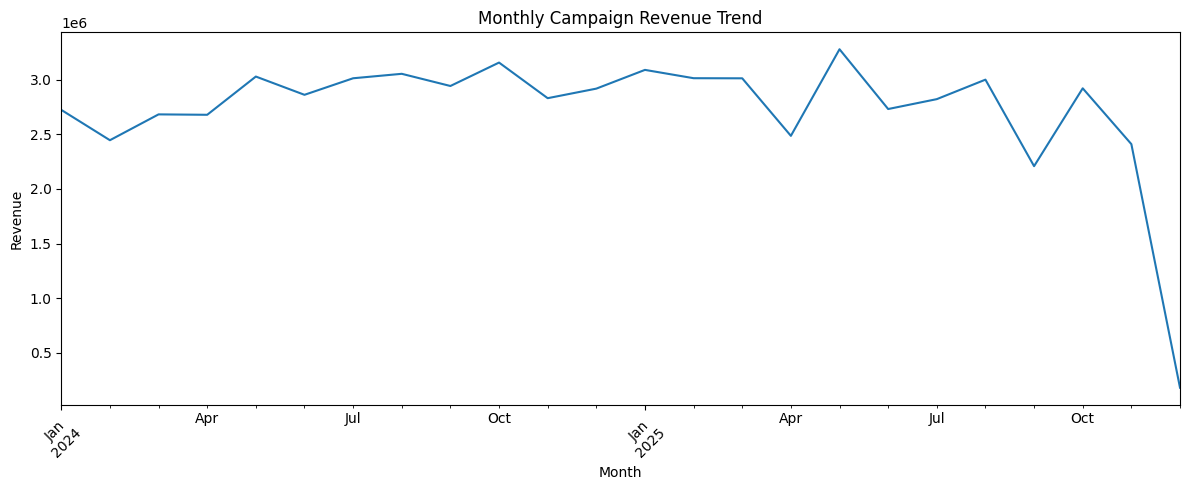

In [166]:
monthly_campaign["Revenue"].plot(
    figsize=(12, 5)
)

plt.title("Monthly Campaign Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 8. Monthly Conversion Trend

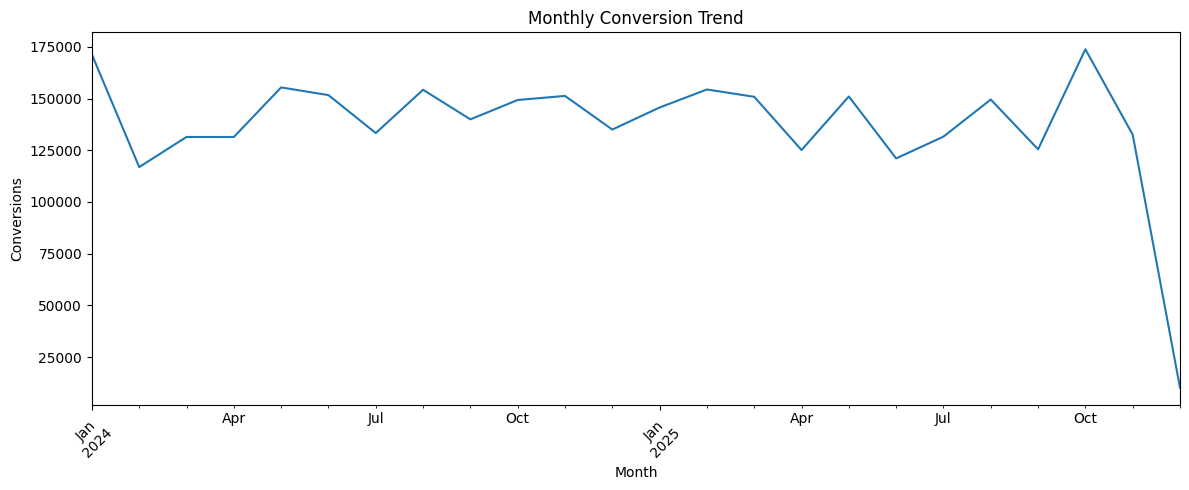

In [168]:
monthly_campaign["Conversions"].plot(
    figsize=(12, 5)
)

plt.title("Monthly Conversion Trend")
plt.xlabel("Month")
plt.ylabel("Conversions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 9. Monthly Marketing Spend Trend

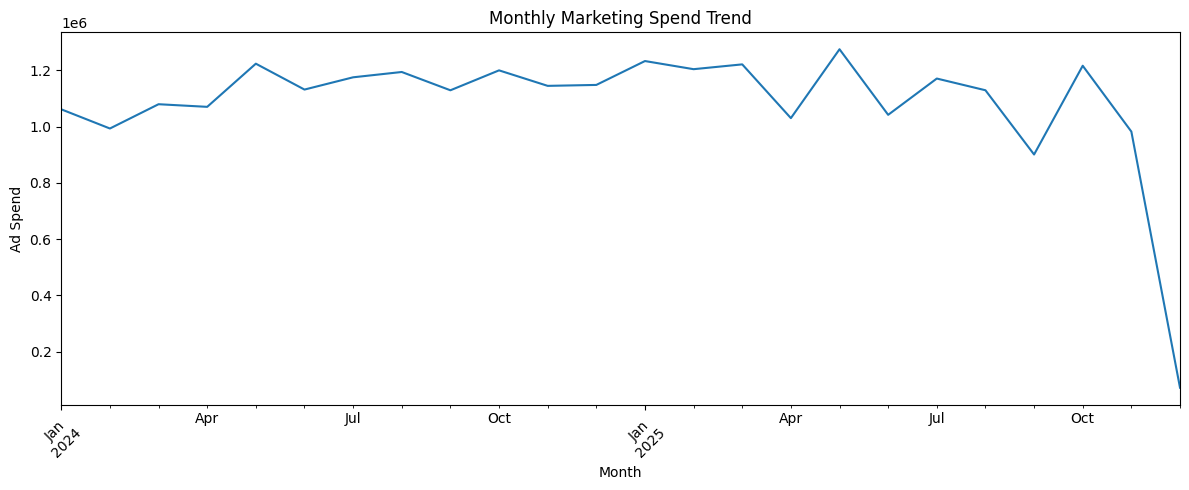

In [170]:
monthly_campaign["Ad_Spend"].plot(
    figsize=(12, 5)
)

plt.title("Monthly Marketing Spend Trend")
plt.xlabel("Month")
plt.ylabel("Ad Spend")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Calculate key marketing KPIs:

## 1. Conversion Rate

In [176]:
total_leads = df["Leads"].sum()
total_conversions = df["Conversions"].sum()

conversion_rate = (
    total_conversions / total_leads
) * 100

print("Conversion Rate:", round(conversion_rate, 2), "%")

Conversion Rate: 50.03 %


## 2. Customer Acquisition Cost (CAC)

In [178]:
total_marketing_spend = df["Ad_Spend"].sum()

acquired_customers = df.loc[
    df["Conversions"] > 0,
    "Customer_ID"
].nunique()

cac = (
    total_marketing_spend / acquired_customers
)

print("Customer Acquisition Cost (CAC):", round(cac, 2))

Customer Acquisition Cost (CAC): 5205.93


## 3. Return on Marketing Investment (ROMI)

In [180]:
total_revenue = df["Revenue"].sum()
total_marketing_spend = df["Ad_Spend"].sum()

romi = (
    (total_revenue - total_marketing_spend)
    / total_marketing_spend
) * 100

print("ROMI:", round(romi, 2), "%")

ROMI: 151.75 %


## 4. Click Through Rate (CTR)

In [182]:
total_impressions = df["Impressions"].sum()
total_clicks = df["Clicks"].sum()

ctr = (
    total_clicks / total_impressions
) * 100
print("Click Through Rate (CTR):", round(ctr, 2), "%")

Click Through Rate (CTR): 10.08 %


## 5. Cost Per Lead (CPL)

In [184]:
total_marketing_spend = df["Ad_Spend"].sum()
total_leads = df["Leads"].sum()

cpl = (
    total_marketing_spend / total_leads
)

print("Cost Per Lead (CPL):", round(cpl, 2))

Cost Per Lead (CPL): 3.96


In [185]:
total_marketing_spend = df["Ad_Spend"].sum()
total_leads = df["Leads"].sum()

cpl = (
    total_marketing_spend / total_leads
)

print("Cost Per Lead (CPL):", round(cpl, 2))

Cost Per Lead (CPL): 3.96


# 6. Customer Engagement Rate

In [187]:
total_engagements = df["Engagements"].sum()
total_impressions = df["Impressions"].sum()

engagement_rate = (
    total_engagements / total_impressions
) * 100

print(
    "Customer Engagement Rate:",
    round(engagement_rate, 2),
    "%"
)

Customer Engagement Rate: 20.04 %


# Calculate All KPIs Together

In [189]:
# ==========================================
# MARKETING KPI CALCULATION
# ==========================================

total_impressions = df["Impressions"].sum()
total_clicks = df["Clicks"].sum()
total_leads = df["Leads"].sum()
total_conversions = df["Conversions"].sum()
total_engagements = df["Engagements"].sum()
total_ad_spend = df["Ad_Spend"].sum()
total_revenue = df["Revenue"].sum()

# Acquired customers
acquired_customers = df.loc[
    df["Conversions"] > 0,
    "Customer_ID"
].nunique()

# KPI calculations
conversion_rate = (
    total_conversions / total_leads
) * 100

cac = (
    total_ad_spend / acquired_customers
)

romi = (
    (total_revenue - total_ad_spend)
    / total_ad_spend
) * 100

ctr = (
    total_clicks / total_impressions
) * 100

cpl = (
    total_ad_spend / total_leads
)

engagement_rate = (
    total_engagements / total_impressions
) * 100


# ==========================================
# CREATE KPI TABLE
# ==========================================

kpi_table = pd.DataFrame({
    "KPI": [
        "Conversion Rate",
        "Customer Acquisition Cost (CAC)",
        "Return on Marketing Investment (ROMI)",
        "Click Through Rate (CTR)",
        "Cost Per Lead (CPL)",
        "Customer Engagement Rate"
    ],

    "Value": [
        round(conversion_rate, 2),
        round(cac, 2),
        round(romi, 2),
        round(ctr, 2),
        round(cpl, 2),
        round(engagement_rate, 2)
    ],

    "Unit": [
        "%",
        "Currency",
        "%",
        "%",
        "Currency",
        "%"
    ]
})

print("\n========== MARKETING KPI TABLE ==========")
print(kpi_table)


========== MARKETING KPI TABLE ==========
                                     KPI    Value      Unit
0                        Conversion Rate    50.03         %
1        Customer Acquisition Cost (CAC)  5205.93  Currency
2  Return on Marketing Investment (ROMI)   151.75         %
3               Click Through Rate (CTR)    10.08         %
4                    Cost Per Lead (CPL)     3.96  Currency
5               Customer Engagement Rate    20.04         %


# SQL Analysis

In [246]:
import sqlite3
conn = sqlite3.connect("marketing_analysis.db")
print("SQLite database connected successfully!")

SQLite database connected successfully!


In [247]:
df.dtypes

Campaign_ID                       str
Campaign_Name                     str
Campaign_Type                     str
Marketing_Channel                 str
Campaign_Start_Date    datetime64[us]
Campaign_End_Date      datetime64[us]
Customer_ID                     int64
Customer_Name                     str
Age                             Int64
Gender                            str
City                              str
State                             str
Country                           str
Customer_Segment                  str
Product_Category                  str
Product_Name                      str
Impressions                     Int64
Clicks                          Int64
Leads                           Int64
Conversions                     Int64
Engagements                     Int64
Ad_Spend                      float64
Revenue                       float64
Profit                        float64
Bounce_Rate                   float64
Session_Duration              float64
Purchase_Amo

In [248]:
for col in df.columns:
    print(col, df[col].dtype)

Campaign_ID str
Campaign_Name str
Campaign_Type str
Marketing_Channel str
Campaign_Start_Date datetime64[us]
Campaign_End_Date datetime64[us]
Customer_ID int64
Customer_Name str
Age Int64
Gender str
City str
State str
Country str
Customer_Segment str
Product_Category str
Product_Name str
Impressions Int64
Clicks Int64
Leads Int64
Conversions Int64
Engagements Int64
Ad_Spend float64
Revenue float64
Profit float64
Bounce_Rate float64
Session_Duration float64
Purchase_Amount float64
Device_Type str
Payment_Method str
Campaign_Status str
Customer_Feedback str
Customer_Rating Int64
Purchase_Date datetime64[us]
Age_Group category
Purchase_Behavior category
Engagement_Level category
Campaign_Month str


In [249]:
for col in df.columns:
    if str(df[col].dtype).startswith("period"):
        df[col] = df[col].astype(str)

In [250]:
df.dtypes

Campaign_ID                       str
Campaign_Name                     str
Campaign_Type                     str
Marketing_Channel                 str
Campaign_Start_Date    datetime64[us]
Campaign_End_Date      datetime64[us]
Customer_ID                     int64
Customer_Name                     str
Age                             Int64
Gender                            str
City                              str
State                             str
Country                           str
Customer_Segment                  str
Product_Category                  str
Product_Name                      str
Impressions                     Int64
Clicks                          Int64
Leads                           Int64
Conversions                     Int64
Engagements                     Int64
Ad_Spend                      float64
Revenue                       float64
Profit                        float64
Bounce_Rate                   float64
Session_Duration              float64
Purchase_Amo

In [251]:
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)
tables

,name
0,marketing_campaign
1,marketing_Dataset


In [252]:
print(df.shape)

(5000, 37)


In [253]:
df.head()

,Campaign_ID,Campaign_Name,Campaign_Type,Marketing_Channel,Campaign_Start_Date,Campaign_End_Date,Customer_ID,Customer_Name,Age,Gender,...,Device_Type,Payment_Method,Campaign_Status,Customer_Feedback,Customer_Rating,Purchase_Date,Age_Group,Purchase_Behavior,Engagement_Level,Campaign_Month
0,C022,Festive Offer,Sales,Google Ads,2024-10-01,2024-10-25,100001,Customer_1,21,Male,...,Mobile,Card,Paused,Negative,1,2024-10-25,18-25,Low Purchase,High Engagement,2024-10
1,C021,Mega Deal,Awareness,LinkedIn,2025-02-15,2025-03-07,100002,Customer_2,29,Female,...,Tablet,UPI,Active,Positive,3,2025-03-07,26-35,Low Purchase,High Engagement,2025-02
2,C049,Summer Sale,Awareness,LinkedIn,2024-09-21,2024-09-28,100003,Customer_3,44,Male,...,Mobile,Card,Active,Positive,5,2024-09-28,36-50,Medium Purchase,High Engagement,2024-09
3,C039,Mega Deal,Sales,Facebook,2024-07-05,2024-07-25,100004,Customer_4,38,Female,...,Desktop,Card,Active,Negative,4,2024-07-25,36-50,Low Purchase,High Engagement,2024-07
4,C012,Mega Deal,Sales,Google Ads,2025-09-07,2025-09-18,100005,Customer_5,22,Male,...,Tablet,Cash,Active,Negative,5,2025-09-18,18-25,Low Purchase,High Engagement,2025-09


In [254]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_rows
FROM Marketing_Dataset;
""", conn)

,total_rows
0,5000


In [255]:
for col in df.columns:
    if str(df[col].dtype).startswith("period"):
        df[col] = df[col].astype(str)

In [261]:
df.to_sql(
    "marketing_Dataset",
    conn,
    if_exists="replace",
    index=False
)

print("Data imported successfully!")

Data imported successfully!


In [257]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_rows
FROM Marketing_Dataset;
""", conn)

,total_rows
0,5000


In [258]:
pd.read_sql_query("""
SELECT *
FROM marketing_Dataset
LIMIT 10;
""", conn)

,Campaign_ID,Campaign_Name,Campaign_Type,Marketing_Channel,Campaign_Start_Date,Campaign_End_Date,Customer_ID,Customer_Name,Age,Gender,...,Device_Type,Payment_Method,Campaign_Status,Customer_Feedback,Customer_Rating,Purchase_Date,Age_Group,Purchase_Behavior,Engagement_Level,Campaign_Month
0,C022,Festive Offer,Sales,Google Ads,2024-10-01 00:00:00,2024-10-25 00:00:00,100001,Customer_1,21,Male,...,Mobile,Card,Paused,Negative,1,2024-10-25 00:00:00,18-25,Low Purchase,High Engagement,2024-10
1,C021,Mega Deal,Awareness,LinkedIn,2025-02-15 00:00:00,2025-03-07 00:00:00,100002,Customer_2,29,Female,...,Tablet,UPI,Active,Positive,3,2025-03-07 00:00:00,26-35,Low Purchase,High Engagement,2025-02
2,C049,Summer Sale,Awareness,LinkedIn,2024-09-21 00:00:00,2024-09-28 00:00:00,100003,Customer_3,44,Male,...,Mobile,Card,Active,Positive,5,2024-09-28 00:00:00,36-50,Medium Purchase,High Engagement,2024-09
3,C039,Mega Deal,Sales,Facebook,2024-07-05 00:00:00,2024-07-25 00:00:00,100004,Customer_4,38,Female,...,Desktop,Card,Active,Negative,4,2024-07-25 00:00:00,36-50,Low Purchase,High Engagement,2024-07
4,C012,Mega Deal,Sales,Google Ads,2025-09-07 00:00:00,2025-09-18 00:00:00,100005,Customer_5,22,Male,...,Tablet,Cash,Active,Negative,5,2025-09-18 00:00:00,18-25,Low Purchase,High Engagement,2025-09
5,C008,New Launch,Promotion,Google Ads,2025-02-25 00:00:00,2025-03-13 00:00:00,100006,Customer_6,48,Male,...,Tablet,UPI,Completed,Neutral,4,2025-03-13 00:00:00,36-50,Low Purchase,High Engagement,2025-02
6,C049,Flash Sale,Promotion,Facebook,2024-10-02 00:00:00,2024-10-31 00:00:00,100007,Customer_7,59,Female,...,Tablet,Cash,Active,Neutral,4,2024-10-31 00:00:00,51+,Low Purchase,High Engagement,2024-10
7,C045,Festive Offer,Sales,Email,2024-08-02 00:00:00,2024-08-23 00:00:00,100008,Customer_8,56,Male,...,Tablet,Net Banking,Completed,Neutral,1,2024-08-23 00:00:00,51+,Low Purchase,High Engagement,2024-08
8,C005,Summer Sale,Awareness,Facebook,2024-08-20 00:00:00,2024-08-28 00:00:00,100009,Customer_9,40,Male,...,Desktop,Cash,Completed,Negative,3,2024-08-28 00:00:00,36-50,Low Purchase,High Engagement,2024-08
9,C050,New Launch,Sales,LinkedIn,2024-11-03 00:00:00,2024-11-22 00:00:00,100010,Customer_10,42,Male,...,Desktop,UPI,Completed,Negative,5,2024-11-22 00:00:00,36-50,Low Purchase,High Engagement,2024-11


### Display Records

In [269]:
run_query("""
SELECT *
FROM marketing_Dataset;
""")

,Campaign_ID,Campaign_Name,Campaign_Type,Marketing_Channel,Campaign_Start_Date,Campaign_End_Date,Customer_ID,Customer_Name,Age,Gender,...,Device_Type,Payment_Method,Campaign_Status,Customer_Feedback,Customer_Rating,Purchase_Date,Age_Group,Purchase_Behavior,Engagement_Level,Campaign_Month
0,C022,Festive Offer,Sales,Google Ads,2024-10-01 00:00:00,2024-10-25 00:00:00,100001,Customer_1,21,Male,...,Mobile,Card,Paused,Negative,1,2024-10-25 00:00:00,18-25,Low Purchase,High Engagement,2024-10
1,C021,Mega Deal,Awareness,LinkedIn,2025-02-15 00:00:00,2025-03-07 00:00:00,100002,Customer_2,29,Female,...,Tablet,UPI,Active,Positive,3,2025-03-07 00:00:00,26-35,Low Purchase,High Engagement,2025-02
2,C049,Summer Sale,Awareness,LinkedIn,2024-09-21 00:00:00,2024-09-28 00:00:00,100003,Customer_3,44,Male,...,Mobile,Card,Active,Positive,5,2024-09-28 00:00:00,36-50,Medium Purchase,High Engagement,2024-09
3,C039,Mega Deal,Sales,Facebook,2024-07-05 00:00:00,2024-07-25 00:00:00,100004,Customer_4,38,Female,...,Desktop,Card,Active,Negative,4,2024-07-25 00:00:00,36-50,Low Purchase,High Engagement,2024-07
4,C012,Mega Deal,Sales,Google Ads,2025-09-07 00:00:00,2025-09-18 00:00:00,100005,Customer_5,22,Male,...,Tablet,Cash,Active,Negative,5,2025-09-18 00:00:00,18-25,Low Purchase,High Engagement,2025-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,C019,New Launch,Promotion,Google Ads,2024-01-30 00:00:00,2024-02-15 00:00:00,104996,Customer_4996,28,Male,...,Mobile,Cash,Active,Neutral,2,2024-02-15 00:00:00,26-35,Low Purchase,High Engagement,2024-01
4996,C016,Summer Sale,Sales,LinkedIn,2025-02-01 00:00:00,2025-02-25 00:00:00,104997,Customer_4997,30,Female,...,Tablet,UPI,Completed,Negative,2,2025-02-25 00:00:00,26-35,Low Purchase,High Engagement,2025-02
4997,C016,New Launch,Promotion,Email,2025-05-26 00:00:00,2025-06-21 00:00:00,104998,Customer_4998,24,Male,...,Tablet,Cash,Paused,Neutral,1,2025-06-21 00:00:00,18-25,Low Purchase,High Engagement,2025-05
4998,C044,New Launch,Awareness,LinkedIn,2024-12-11 00:00:00,2024-12-19 00:00:00,104999,Customer_4999,23,Male,...,Tablet,UPI,Paused,Neutral,1,2024-12-19 00:00:00,18-25,Low Purchase,High Engagement,2024-12


### Total Revenue, Spend and Profit

In [271]:
query = """
SELECT
    SUM(Revenue) AS Total_Revenue,
    SUM(Ad_Spend) AS Total_Ad_Spend,
    SUM(Profit) AS Total_Profit
FROM marketing_Dataset;
"""

pd.read_sql_query(query, conn)

,Total_Revenue,Total_Ad_Spend,Total_Profit
0,6.552990e+07,26029630.12,40107359.7


### Revenue by Campaign

In [273]:
query = """
SELECT
    Campaign_Name,
    SUM(Revenue) AS Total_Revenue
FROM marketing_Dataset
GROUP BY Campaign_Name
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Campaign_Name,Total_Revenue
0,Mega Deal,1.365331e+07
1,New Launch,1.363934e+07
2,Flash Sale,1.319315e+07
3,Summer Sale,1.268411e+07
4,Festive Offer,1.235999e+07


### Campaigns with Revenue Greater Than Average

In [276]:
query = """
SELECT
    Campaign_Name,
    SUM(Revenue) AS Total_Revenue
FROM marketing_Dataset
GROUP BY Campaign_Name
HAVING SUM(Revenue) >
(
    SELECT AVG(Revenue)
    FROM marketing_Dataset
)
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Campaign_Name,Total_Revenue
0,Mega Deal,1.365331e+07
1,New Launch,1.363934e+07
2,Flash Sale,1.319315e+07
3,Summer Sale,1.268411e+07
4,Festive Offer,1.235999e+07


### Revenue by Marketing Channel

In [278]:
query = """
SELECT
    Marketing_Channel,
    SUM(Revenue) AS Total_Revenue,
    SUM(Conversions) AS Total_Conversions
FROM marketing_Dataset
GROUP BY Marketing_Channel
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Marketing_Channel,Total_Revenue,Total_Conversions
0,LinkedIn,1.724839e+07,866430
1,Instagram,1.246045e+07,581792
2,Email,1.244988e+07,611090
3,Facebook,1.179290e+07,637028
4,Google Ads,1.157828e+07,595545


### Customer Segment Analysis

In [279]:
query = """
SELECT
    Customer_Segment,
    COUNT(DISTINCT Customer_ID) AS Total_Customers,
    SUM(Revenue) AS Total_Revenue,
    SUM(Conversions) AS Total_Conversions
FROM marketing_Dataset
GROUP BY Customer_Segment
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Customer_Segment,Total_Customers,Total_Revenue,Total_Conversions
0,Returning,1709,2.224869e+07,1137402
1,VIP,1615,2.169958e+07,1059385
2,New,1676,2.158163e+07,1095098


### Region-wise Performance

In [280]:
query = """
SELECT
    State,
    COUNT(DISTINCT Customer_ID) AS Total_Customers,
    SUM(Revenue) AS Total_Revenue,
    SUM(Conversions) AS Total_Conversions
FROM marketing_Dataset
GROUP BY State
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,State,Total_Customers,Total_Revenue,Total_Conversions
0,Maharashtra,2018,2.654735e+07,1360214
1,Telangana,1015,1.339753e+07,655360
2,Karnataka,1007,1.302342e+07,662323
3,Delhi,960,1.256159e+07,613988


### Product Category Performance

In [281]:
query = """
SELECT
    Product_Category,
    SUM(Revenue) AS Total_Revenue,
    SUM(Profit) AS Total_Profit,
    SUM(Conversions) AS Total_Conversions
FROM marketing_Dataset
GROUP BY Product_Category
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product_Category,Total_Revenue,Total_Profit,Total_Conversions
0,Home,1.357171e+07,8273571.37,648848
1,Fashion,1.324746e+07,8204016.54,618043
2,Beauty,1.317917e+07,8079580.51,708123
3,Grocery,1.292850e+07,7858857.90,684640
4,Electronics,1.260306e+07,7691333.38,632231


### Customers by gender

In [282]:
run_query("""
SELECT
    Gender,
    COUNT(DISTINCT Customer_ID) AS total_customers
FROM marketing_Dataset
GROUP BY Gender;
""")

,Gender,total_customers
0,Female,2502
1,Male,2498


### Customers by country

In [288]:
run_query("""
SELECT
    Country,
    COUNT(DISTINCT Customer_ID) AS total_customers
FROM marketing_Dataset
GROUP BY Country
ORDER BY total_customers DESC;
""")

,Country,total_customers
0,India,5000


### Customers by city

In [289]:
run_query("""
SELECT
    City,
    COUNT(DISTINCT Customer_ID) AS total_customers
FROM marketing_Dataset
GROUP BY City
ORDER BY total_customers DESC;
""")

,City,total_customers
0,Mumbai,1362
1,Bengaluru,930
2,Hyderabad,919
3,Pune,915
4,Delhi,874


### Campaign-wise KPI Analysis

In [291]:
query = """
SELECT
    Campaign_Name,

    SUM(Impressions) AS Impressions,

    SUM(Clicks) AS Clicks,

    SUM(Leads) AS Leads,

    SUM(Conversions) AS Conversions,

    SUM(Ad_Spend) AS Ad_Spend,

    SUM(Revenue) AS Revenue,

    ROUND(
        SUM(Clicks) * 100.0 /
        NULLIF(SUM(Impressions), 0),
        2
    ) AS CTR,

    ROUND(
        SUM(Conversions) * 100.0 /
        NULLIF(SUM(Leads), 0),
        2
    ) AS Conversion_Rate,

    ROUND(
        SUM(Ad_Spend) /
        NULLIF(SUM(Leads), 0),
        2
    ) AS CPL,

    ROUND(
        (
            (SUM(Revenue) - SUM(Ad_Spend))
            * 100.0 /
            NULLIF(SUM(Ad_Spend), 0)
        ),
        2
    ) AS ROMI

FROM marketing_Dataset

GROUP BY Campaign_Name

ORDER BY ROMI DESC;
"""

pd.read_sql_query(query, conn)

,Campaign_Name,Impressions,Clicks,Leads,Conversions,Ad_Spend,Revenue,CTR,Conversion_Rate,CPL,ROMI
0,Summer Sale,24338367,2529976,1280122,646257,4980675.06,1.268411e+07,10.40,50.48,3.89,154.67
1,New Launch,25394886,2519943,1291181,640443,5363597.44,1.363934e+07,9.92,49.60,4.15,154.29
2,Festive Offer,24020779,2483870,1318325,650841,4924033.32,1.235999e+07,10.34,49.37,3.74,151.01
3,Mega Deal,27403658,2664619,1353306,680228,5467489.93,1.365331e+07,9.72,50.26,4.04,149.72
4,Flash Sale,26167433,2632990,1336624,674116,5293834.37,1.319315e+07,10.06,50.43,3.96,149.22
